# 05: 量子位相推定 (QPE) — 回路の実装

ノート `05_quantum_phase_estimation.md` の QPE 回路を Qiskit で実装し、シミュレーションで検証する。

**内容:**
1. 2ビット QPE 回路（具体例: $\varphi = 1/4$）
2. 一般的な QPE 回路

> **記法の注意:** ノートと Qiskit ではインデックスの始まり（1 vs 0）やケット表記のビット順が異なる。詳しくは [01_qubit_ordering.ipynb](01_qubit_ordering.ipynb) を参照。物理的な結果には影響しない。

In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate
import numpy as np

**インポートの解説:**

- `QuantumCircuit`, `QuantumRegister`, `ClassicalRegister`: 量子回路の構築に使う基本クラス（03 notebook 参照）。
- `Statevector`: 状態ベクトルシミュレーション用。回路を実行せずに最終状態を直接計算する。
- `Operator`: ユニタリ行列を Qiskit のゲートとして扱うためのクラス。
- `QFTGate`: Qiskit が提供する量子フーリエ変換のゲート。`QFTGate(n).inverse()` で逆 QFT（$F_N^\dagger$）を生成できる。

## 1. 2ビット QPE（$\varphi = 1/4$）

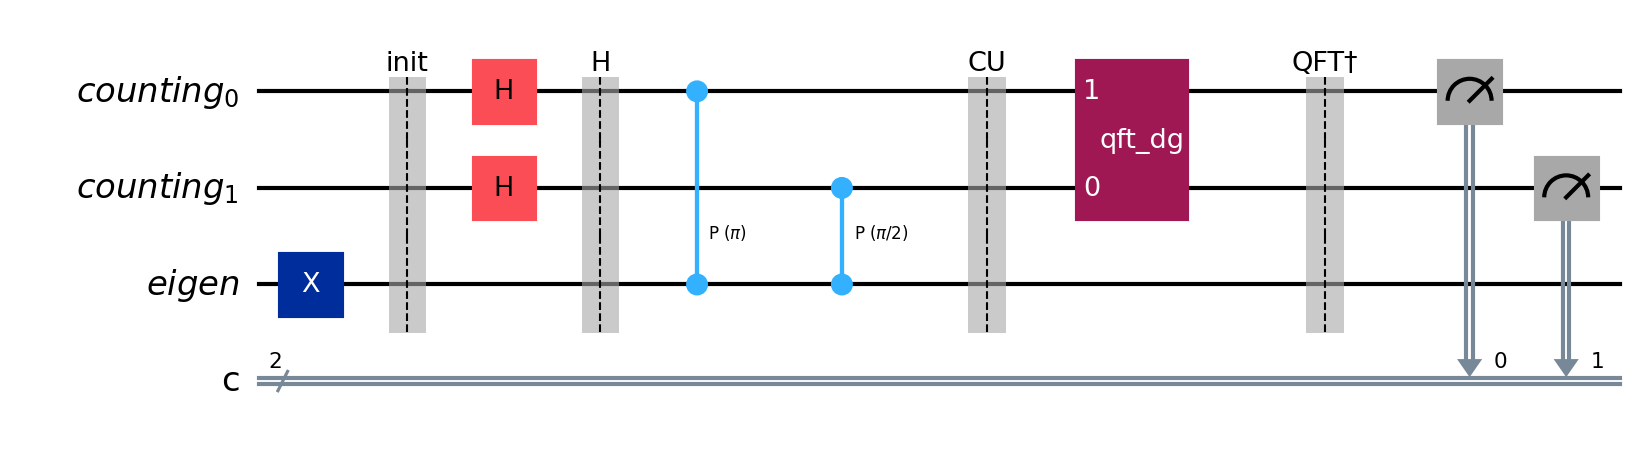

ノート05の具体例と同じ設定で QPE を実装する。

- **ユニタリ演算子 $U$:** 位相ゲート $R_\varphi = \begin{pmatrix} 1 & 0 \\ 0 & e^{2\pi i \varphi} \end{pmatrix}$
- **固有ベクトル:** $|u\rangle = |1\rangle$（固有値 $e^{2\pi i \varphi}$）
- **位相:** $\varphi = 1/4$
- **計数レジスタ:** $n = 2$ ビット（$2^n = 4$）
- **期待される測定結果:** $s = \varphi \cdot 2^n = 1/4 \cdot 4 = 1$ → 二進数で $01$

In [ ]:
def qpe_2bit(phi):
    """2ビット QPE 回路を構築する。
    
    U = R_φ, 固有ベクトル |u⟩ = |1⟩ とする。
    """
    counting = QuantumRegister(2, "counting")
    eigen = QuantumRegister(1, "eigen")
    c = ClassicalRegister(2, "c")
    qc = QuantumCircuit(counting, eigen, c)

    # 固有ベクトル |1⟩ を準備
    qc.x(eigen[0])
    qc.barrier(label="init")

    # ステップ 1: アダマール
    qc.h(counting[0])
    qc.h(counting[1])
    qc.barrier(label="H")

    # ステップ 2: 制御ユニタリ
    # counting_0（最上位ビット）が制御 U^{2^1} = U^2 → 位相 2π*φ*2
    qc.cp(2 * np.pi * phi * 2, counting[0], eigen[0])
    # counting_1（最下位ビット）が制御 U^{2^0} = U^1 → 位相 2π*φ
    qc.cp(2 * np.pi * phi, counting[1], eigen[0])
    qc.barrier(label="CU")

    # ステップ 3: 逆 QFT
    # QFTGate は append 時にリストの先頭を LSB として扱うが、
    # この回路では counting_0 が MSB なので、逆順で渡す。
    qft_inv = QFTGate(2).inverse()
    qc.append(qft_inv, [counting[1], counting[0]])
    qc.barrier(label="QFT†")

    # ステップ 4: 測定
    qc.measure(counting, c)

    return qc

# 回路を構築
qc_2bit = qpe_2bit(1/4)
print(f"2ビット QPE 回路: {qc_2bit.num_qubits} 量子ビット, {qc_2bit.num_clbits} 古典ビット")

**コードの解説:**

- `qc.x(eigen[0])`: $X$ ゲート（NOT ゲート）で $\vert 0\rangle \to \vert 1\rangle$ にする。固有ベクトル $\vert u\rangle = \vert 1\rangle$ の準備。
- `qc.cp(theta, control, target)`: 制御位相ゲート。制御ビットが $\vert 1\rangle$ のときだけ標的ビットに位相 $e^{i\theta}$ を掛ける。$U^{2^k}$ の位相は $2\pi\varphi \cdot 2^k$ なので、`theta = 2 * np.pi * phi * power` とする。
- `qc.append(qft_inv, [counting[1], counting[0]])`: 逆 QFT を計数レジスタに適用する。`QFTGate` は `append` 時にリストの先頭を LSB として扱うが、この回路では `counting[0]` が MSB なので、逆順 `[counting[1], counting[0]]` で渡す。
- `qc.measure(counting, c)`: 計数レジスタ全体を測定し、結果を古典レジスタ `c` に格納する。

### 状態ベクトルで各ステップを追跡

ノート05のステップ 1〜3 に対応する状態の変化を確認する。

測定なしの回路を使い、状態ベクトルを直接取得する。

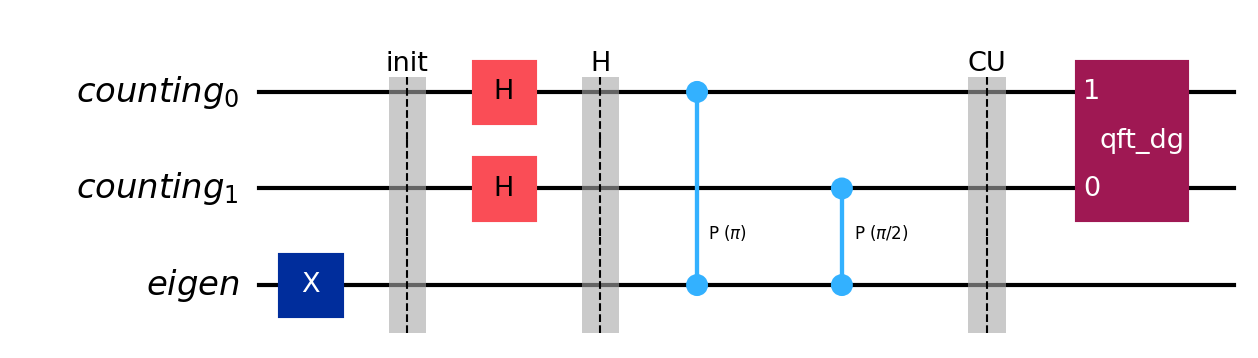

In [22]:
phi = 1/4

# 測定なしの回路で状態ベクトルを追跡
def qpe_2bit_no_measure(phi):
    """測定なしの 2ビット QPE 回路（状態ベクトル取得用）。"""
    qc = QuantumCircuit(3)  # q0=counting_0, q1=counting_1, q2=eigen

    # 固有ベクトル |1⟩
    qc.x(2)

    # ステップ 1: アダマール
    qc.h(0)
    qc.h(1)

    # ステップ 2: 制御ユニタリ
    # counting_0 が制御 U^2
    qc.cp(2 * np.pi * phi * 2, 0, 2)
    # counting_1 が制御 U^1
    qc.cp(2 * np.pi * phi, 1, 2)

    # ステップ 3: 逆 QFT
    # QFTGate は qubit 0 を LSB として扱うが、この回路では q0 が MSB。
    # 量子ビットの順序を逆にして append し、MSB/LSB の対応を合わせる。
    qft_inv = QFTGate(2).inverse()
    qc.append(qft_inv, [1, 0])

    return qc


qc_track = qpe_2bit_no_measure(phi)
sv = Statevector.from_instruction(qc_track)

print(f"位相 φ = {phi}")
print(f"期待される測定結果: s = {phi} × 2² = {int(phi * 4)}\n")
print("最終状態の振幅（counting は c0 c1 の順、c0 が最上位ビット）:")
for i, amp in enumerate(sv):
    if abs(amp) > 1e-10:
        # q0=counting_0, q1=counting_1, q2=eigen
        c0 = (i >> 0) & 1  # counting_0
        c1 = (i >> 1) & 1  # counting_1
        e = (i >> 2) & 1   # eigen
        counting_val = c0 * 2 + c1  # counting_0 が最上位
        print(f"  |counting={c0}{c1}⟩|eigen={e}⟩ (s={counting_val}): {amp:.4f}")

print(f"\n→ 計数レジスタの測定結果: s = {int(phi * 4)}, φ̃ = s/2² = {int(phi * 4)}/4 = {phi}")

位相 φ = 0.25
期待される測定結果: s = 0.25 × 2² = 1

最終状態の振幅（counting は c0 c1 の順、c0 が最上位ビット）:
  |counting=01⟩|eigen=1⟩ (s=1): 1.0000-0.0000j

→ 計数レジスタの測定結果: s = 1, φ̃ = s/2² = 1/4 = 0.25


**コードの解説:**

- `qc.cp(theta, control, target)`: 制御位相ゲート。制御ビットが $\vert 1\rangle$ のときだけ標的ビットに位相 $e^{i\theta}$ を掛ける。`qc.cp(2*np.pi*phi*2, 0, 2)` は制御 $U^2$ に相当する。
- `(i >> k) & 1`: ビット演算で状態ベクトルのインデックス `i` から各量子ビットの値を取り出す。Qiskit のリトルエンディアン規約では `i` の $k$ ビット目が $q_k$ の値に対応する。
- `qc.append(qft_inv, [1, 0])`: 逆 QFT を計数レジスタに適用する。`QFTGate` は `append` 時にリストの先頭を LSB（最下位ビット）として扱うが、この回路では $q_0$ が MSB（最上位ビット）である。そのため `[0, 1]` ではなく `[1, 0]` と逆順で渡し、MSB/LSB の対応を合わせている。

## 2. 一般的な QPE 回路

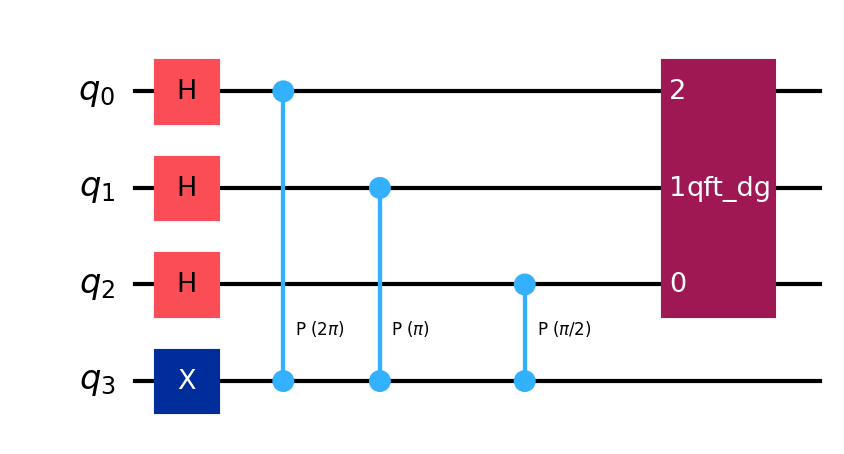

計数レジスタのビット数 $n$ を変えて QPE を実行する。

In [27]:
def qpe_general(phi, n_counting):
    """一般的な QPE 回路を構築する（測定なし）。
    
    U = R_φ, 固有ベクトル |u⟩ = |1⟩ とする。
    n_counting: 計数レジスタのビット数
    """
    n_total = n_counting + 1  # +1 for eigen register
    qc = QuantumCircuit(n_total)

    # 固有ベクトル |1⟩
    qc.x(n_counting)

    # ステップ 1: アダマール
    for i in range(n_counting):
        qc.h(i)

    # ステップ 2: 制御ユニタリ
    # qubit k（k=0 が最上位）が制御 U^{2^{n-1-k}}
    for k in range(n_counting):
        power = 2 ** (n_counting - 1 - k)
        qc.cp(2 * np.pi * phi * power, k, n_counting)

    # ステップ 3: 逆 QFT
    # QFTGate は append 時にリストの先頭を LSB として扱うが、
    # この回路では qubit 0 が MSB なので、逆順で渡す。
    # 例: n_counting=3 なら list(range(2, -1, -1)) = [2, 1, 0]
    qft_inv = QFTGate(n_counting).inverse()
    counting_qubits_reversed = list(range(n_counting - 1, -1, -1))
    qc.append(qft_inv, counting_qubits_reversed)

    return qc


def run_qpe(phi, n_counting):
    """QPE を実行し、測定確率を表示する。"""
    qc = qpe_general(phi, n_counting)
    sv = Statevector.from_instruction(qc)
    probs = {}

    for i, amp in enumerate(sv):
        prob = abs(amp) ** 2
        if prob > 1e-10:
            # 計数レジスタの値を取得
            bits = []
            for k in range(n_counting):
                bits.append((i >> k) & 1)
            # bits[0] が qubit 0（最上位）
            s = sum(bits[k] * 2 ** (n_counting - 1 - k) for k in range(n_counting))
            if s not in probs:
                probs[s] = 0.0
            probs[s] += prob

    N = 2 ** n_counting
    print(f"φ = {phi}, n = {n_counting} ビット (2^n = {N})")
    print(f"φ × 2^n = {phi * N:.4f}")
    print(f"{'s':>5}  {'s/2^n':>10}  {'確率':>10}")
    print("-" * 30)
    for s in sorted(probs.keys()):
        if probs[s] > 1e-10:
            print(f"{s:5d}  {s/N:10.6f}  {probs[s]:10.6f}")
    print()
    return probs

**コードの解説:**

`qpe_general(phi, n_counting)`:
- セクション1の `qpe_2bit` を任意のビット数 $n$ に一般化した関数。測定なしの回路を返す（`Statevector.from_instruction()` で状態ベクトルを取得するため）。
- `qc.x(n_counting)`: 計数レジスタの後ろにある eigen レジスタ（$q_n$）を $\vert 1\rangle$ にする。
- `counting_qubits_reversed`: `QFTGate` のビット順問題（セクション1の解説参照）に対応するため、計数レジスタの量子ビットを逆順で渡す。

`run_qpe(phi, n_counting)`:
- `qpe_general` で回路を構築・実行し、状態ベクトルから計数レジスタの測定確率を計算して表示する。

### 2.1 位相が $n$ ビットで正確に表せる場合

$\varphi = 1/4$ は $n = 2$ ビットで正確に表せる（$s = 1$）。確率 1 で正しい結果が得られるはずである。

In [30]:
# φ = 1/4, n = 2: 正確に表せる
run_qpe(1/4, 2)

# φ = 3/8, n = 3: 正確に表せる (s = 3)
run_qpe(3/8, 3)

φ = 0.25, n = 2 ビット (2^n = 4)
φ × 2^n = 1.0000
    s       s/2^n          確率
------------------------------
    1    0.250000    1.000000

φ = 0.375, n = 3 ビット (2^n = 8)
φ × 2^n = 3.0000
    s       s/2^n          確率
------------------------------
    3    0.375000    1.000000



{3: np.float64(0.9999999999999991)}

### 2.2 位相が $n$ ビットで正確に表せない場合

$\varphi = 1/3$ は二進小数で無限に続くため、有限ビットでは正確に表せない。ノート05で説明した通り、最も近い値が最大確率で得られるが、他の値も確率を持つ。

ビット数 $n$ を増やすと精度が向上する様子を確認する。

In [31]:
# φ = 1/3 を n = 3, 6 ビットで推定
for n in [3, 6]:
    probs = run_qpe(1/3, n)
    # 最大確率の s を見つける
    best_s = max(probs, key=probs.get)
    N = 2 ** n
    print(f"  → 最良推定: s = {best_s}, φ̃ = {best_s}/{N} = {best_s/N:.6f}")
    print(f"     真の値との誤差: |φ̃ - φ| = {abs(best_s/N - 1/3):.6f}")
    print()

φ = 0.3333333333333333, n = 3 ビット (2^n = 8)
φ × 2^n = 2.6667
    s       s/2^n          確率
------------------------------
    0    0.000000    0.015625
    1    0.125000    0.031622
    2    0.250000    0.174940
    3    0.375000    0.687838
    4    0.500000    0.046875
    5    0.625000    0.018619
    6    0.750000    0.012560
    7    0.875000    0.011922

  → 最良推定: s = 3, φ̃ = 3/8 = 0.375000
     真の値との誤差: |φ̃ - φ| = 0.041667

φ = 0.3333333333333333, n = 6 ビット (2^n = 64)
φ × 2^n = 21.3333
    s       s/2^n          確率
------------------------------
    0    0.000000    0.000244
    1    0.015625    0.000259
    2    0.031250    0.000277
    3    0.046875    0.000298
    4    0.062500    0.000324
    5    0.078125    0.000355
    6    0.093750    0.000392
    7    0.109375    0.000437
    8    0.125000    0.000494
    9    0.140625    0.000565
   10    0.156250    0.000657
   11    0.171875    0.000776
   12    0.187500    0.000936
   13    0.203125    0.001157
   14    0.218750    